In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
import pandas as pd
#enable interactive plots
#%jsroot on  

#root.gStyle.SetOptStat(1111)
#root.gStyle.SetOptFit(1111) 
root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(0) 

#%jsroot on

Welcome to JupyROOT 6.30/04


34.47408716744957 9.951357903657765
34.49990472868437 9.947909782020282
34.594628911526925 9.9581906116439
34.59408062226537 9.968922562588595
34.60256210640651 9.744505088855185
34.56959788024396 9.62674884150276
34.5844643904703 9.624008988903512
34.56116818120988 9.686463421212238
34.4787427777095 9.805306225812089
34.42531407900496 9.859581981615705


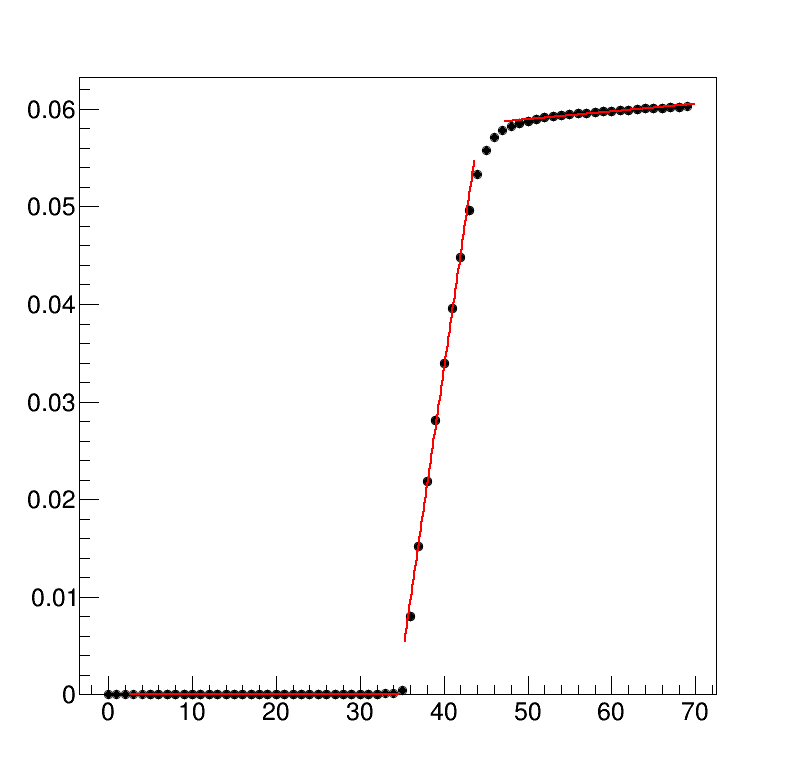

In [2]:
wb = pd.read_excel('/Users/icosivi/Desktop/plot_HPK5/HPK5_16x16_ETLdb.xlsx')

tests_json = []
dtz = datetime(2025, 4, 1, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))
  

n_wafer=28
start_wafer=1
vc_raw = [[] for k in range(n_wafer)]
v_raw = [[] for k in range(n_wafer)]

h = TH1F( "hvgl", "VGL HPK5", 100, 34, 35)
hh = TH1F( "hbulk", "Vbulk HPK5", 100, 8, 12)

file_qa = root.TFile.Open("../../root_files/HPK5_16x16_CVtree.root")
tree_qa = file_qa.Get("Tree")

low_GL_bias = 5.  #limite basso del fit (in voltaggio)
high_GL_bias = 32.  #limite alto del fit (in voltaggio)
low_bulk_bias = 36. #limite basso del fit (in voltaggio)
high_bulk_bias = 43.  #limite alto del fit (in voltaggio)
#low_bulk_bias = 37. #limite basso del fit (in voltaggio)
#high_bulk_bias = 39.  #limite alto del fit (in voltaggio)
k_high = 50.
k_low = 10.

c = root.TCanvas("cdew", "cdew", 800,800)

for event in tree_qa:
      #print(event.event)
  #if event.side==side_file and event.type==sensor_type:
  #if event.side==side_file:
    #if(int(event.CPAD.size())>=start_gl_calculation and int(event.V.size())>=start_gl_calculation ):

      if( event.CPAD.at(event.CPAD.size()-1)<0 ): 
        Cpad = [float(-i) for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Cpad = [i for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.CPAD.size()-1):
           v_raw[event.wafer-start_wafer].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.CPAD.size()-1): 
           v_raw[event.wafer-start_wafer].append(float(i))
           

      non_zero_capacitance = sum(Cpad) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_capacitance!=0):
    
        cv_quality = True
        VGL_CV = -1000.
        Vbulk_CV = -1000.
      
        V_GL_vector = []
        C_GL_vector = []
        V_GL_vector_error = []
        C_GL_vector_error = []
        V_bulk_vector = []
        C_bulk_vector = []
        V_bulk_vector_error = []
        C_bulk_vector_error = []
        V_trail_vector = []
        C_trail_vector = []
        V_trail_vector_error = []
        C_trail_vector_error = []
        
        ####### VGL calculation #####
        for i in range(len(Vbias)-1):

          if Vbias[i]>=low_GL_bias and Vbias[i]<=high_GL_bias:
  
            V_GL_vector.append(float(Vbias[i]))
            C_GL_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_GL_vector_error.append(1/np.sqrt(12))
            C_GL_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
  
  
          if Vbias[i]>=low_bulk_bias and Vbias[i]<=high_bulk_bias:
  
            V_bulk_vector.append(float(Vbias[i]))
            C_bulk_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_bulk_vector_error.append(1/np.sqrt(12))
            C_bulk_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
          
          if Vbias[i]>48. and Vbias[i]<Vbias[len(Vbias)-1]:
            #print(float(Vbias[i]))
            V_trail_vector.append(float(Vbias[i]))
            C_trail_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_trail_vector_error.append(1/np.sqrt(12))
            C_trail_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
        
        V_GL_vector = np.array(V_GL_vector)
        C_GL_vector = np.array(C_GL_vector)
        V_bulk_vector = np.array(V_bulk_vector)
        C_bulk_vector = np.array(C_bulk_vector)
        V_trail_vector = np.array(V_trail_vector)
        C_trail_vector = np.array(C_trail_vector)
        Vbias = np.array(Vbias)
        Cpad = np.array(Cpad)
        g_GL = root.TGraph(len(V_GL_vector),V_GL_vector,C_GL_vector)
        g_bulk = root.TGraph(len(V_bulk_vector),V_bulk_vector,C_bulk_vector)
        g_trail = root.TGraph(len(V_trail_vector),V_trail_vector,C_trail_vector)
        g_total = root.TGraph(len(Vbias),Vbias,1/(Cpad*Cpad))

        g_GL.Fit("pol1","Q")
        f_gl = g_GL.GetFunction("pol1")
        chi_gl = f_gl.GetChisquare()/f_gl.GetNDF()
        
        g_bulk.Fit("pol1","Q")
        f_bulk = g_bulk.GetFunction("pol1")
        chi_bulk = f_bulk.GetChisquare()/f_bulk.GetNDF()
        
        g_trail.Fit("pol1","Q")
        f_trail = g_trail.GetFunction("pol1")
        chi_trail = f_trail.GetChisquare()/f_trail.GetNDF()
        
        #print("Chi2: "+str(chi_gl)+" "+str(chi_bulk)+" "+str(chi_trail))
        
        g_GL.SetMarkerStyle(20)
        g_bulk.SetMarkerStyle(20)
        g_trail.SetMarkerStyle(20)
        g_total.SetMarkerStyle(20)
        g_GL.SetLineWidth(0)
        g_bulk.SetLineWidth(0)
        g_trail.SetLineWidth(0)
        g_total.SetLineWidth(0)
        
        mg = root.TMultiGraph()
        mg.Add(g_total,"cp")
        mg.Add(g_GL,"lp")
        mg.Add(g_bulk,"cp")
        mg.Add(g_trail,"cp")
        c.cd()
        mg.Draw("apl same")
        c.Update()
        #mg.SaveAs("/Users/icosivi/Desktop/pippo/"+str(event.event)+".root")
        
        f_GL = g_GL.GetFunction("pol1")
        f_bulk = g_bulk.GetFunction("pol1")
        f_trail = g_trail.GetFunction("pol1")

        m_GL = f_GL.GetParameter(1)
        q_GL = f_GL.GetParameter(0)
        m_bulk = f_bulk.GetParameter(1)
        q_bulk = f_bulk.GetParameter(0)
        m_trail = f_trail.GetParameter(1)
        q_trail = f_trail.GetParameter(0)


        VGL_CV = (q_bulk-q_GL)/(m_GL-m_bulk)
        Vbulk_CV = (q_trail-q_bulk)/(m_bulk-m_trail) - VGL_CV
        
        pippo = {'component': str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == 3) & (wb['Column'] == 3)]['SerialNumber'].iloc[0]),
                        'type': 'Sensor Test Array CV - Vendor',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': 'HPK',
                        'user_created': 'fsiviero',
                        'version': '0.0',
                        'data':{
                         'vgl_V': VGL_CV,
                         'vbulk_V': Vbulk_CV,
                         'side': 'A',
                         'geometry': '1x1 LGAD',
                         'gain_category': None,
                         'voltage': v_raw[event.wafer-start_wafer],
                         'capacitance': vc_raw[event.wafer-start_wafer] 
                        }
                       }
               
        tests_json.append(pippo)
        
        
        #h.Fill( VGL_CV )
        #hh.Fill( Vbulk_CV )
        print(str(VGL_CV)+" "+str(Vbulk_CV))
        
with open("/Users/icosivi/Desktop/plot_HPK5/Test_Array_Vendor_CV_HPK5.json", 'w') as f:
   json.dump(tests_json, f, indent=4)

In [ ]:
c = root.TCanvas("cw", "cw", 800,800)
c.cd()
hh.GetXaxis().SetTitle("V Bulk [V]")
hh.Draw()
c.Update()

In [ ]:
cc = root.TCanvas("cwd", "cwd", 800,800)
cc.cd()
h.GetXaxis().SetTitle("VGL [V]")
h.Draw()
cc.Update()

In [ ]:
vbd = [213.27962239583334, 214.65983072916666, 215.42724609375, 214.5458984375, 215.67138671875, 215.69173177083334, 215.67464192708334, 215.61604817708334, 213.15511067708334, 216.58121744791666]
vbd_sigma =  [22.879701278351117, 12.07000688140569, 8.84760920474897, 15.25730409440896, 3.1212354873729264, 3.9746130407734603, 3.3115812703004317, 6.72230111641559, 22.903333643379035, 5.724858311302318]

vgl = [34.47408716744957, 34.49990472868437, 34.594628911526925, 34.59408062226537, 34.60256210640651, 34.56959788024396, 34.5844643904703, 34.56116818120988, 34.4787427777095, 34.42531407900496]
vbulk = [9.951357903657765, 9.947909782020282, 9.95819061164393, 9.968922562588595, 9.744505088855185, 9.62674884150276, 9.624008988903512, 9.686463421212238, 9.805306225812089, 9.859581981615705]

In [ ]:
def sort_lists_by_first(list1, list2):
    """Sorts two lists based on the increasing order of the first list.

    Args:
        list1: The list to sort by (determines the order).
        list2: The list to sort in parallel.

    Returns:
        A tuple containing the sorted lists (list1_sorted, list2_sorted).
    """

    # Create a list of tuples (element from list1, element from list2, original index)
    indexed_pairs = [(val1, val2, index) for index, (val1, val2) in enumerate(zip(list1, list2))]

    # Sort the tuples based on the first element (val1)
    sorted_pairs = sorted(indexed_pairs)

    # Unpack the sorted tuples back into two lists
    list1_sorted = [val1 for val1, _, _ in sorted_pairs]
    list2_sorted = [val2 for _, val2, _ in sorted_pairs]

    return list1_sorted, list2_sorted


vgl, vbd = sort_lists_by_first(vgl, vbd)

#print("Sorted list3:", sorted_list3)
#print("Sorted list4:", sorted_list4)

In [ ]:

plt.figure(figsize=(10, 6))
plt.errorbar(vgl, vbd, yerr=[5,5,5,5,5,5,5,5,5,5], marker='o',markersize=10)  

plt.xlabel("VGL [V]",fontsize=18)
plt.ylabel("VBD [V]",fontsize=18)
plt.title("HPK5 - VBD vs VGL",fontsize=24)
plt.xlim(34.4, 34.7) # set the limit of the x axis to 0-9
plt.ylim(200, 230) # set the limit of the x axis to 0-9

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()